# Q1 - Boston Housing: Pre-processing + Multiple Linear Regression

## Settings - change only this cell for the exam dataset

In [1]:
# The exam gives you a CSV named after the question, e.g. "Data_Q1.csv".
CSV_FILE = "Data_Q1.csv"
TARGET   = "MEDV"        # Median value of owner-occupied homes
TEST_SIZE = 0.35         # question says 65% train / 35% test


## Step 1: Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Step 2: Load the dataset

In [3]:
df = pd.read_csv(CSV_FILE)
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,7.2126,0.0,5.49,0,0.550,5.654,8.0,7.6958,7,573,20.3,71.28,10.66,22.6
1,7.0086,0.0,1.33,0,0.609,5.569,60.4,1.8872,4,551,17.8,164.50,7.54,23.1
2,7.1543,20.0,3.43,0,0.463,6.273,13.7,11.3673,3,614,18.4,312.36,14.69,23.5
3,0.8394,0.0,16.93,0,0.770,6.237,26.0,11.4060,4,663,13.2,360.80,29.85,11.9
4,0.2593,12.5,6.90,0,0.508,5.668,34.2,7.1066,24,649,14.5,235.74,26.93,15.4


## Step 3: Explore the data

In [4]:
print("Shape:", df.shape)     # expect 506 rows x 14 columns
df.info()


Shape: (506, 14)
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       494 non-null    float64
 6   AGE      494 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    494 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


## Step 4: Summary statistics

In [5]:
df.describe()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,494.000000,494.000000,506.000000,506.000000,506.000000,506.000000,506.000000,494.000000,506.000000
mean,2.989723,21.758893,13.791146,0.086957,0.620998,6.317334,48.740486,6.692212,6.167984,449.258893,17.089921,187.578893,20.218826,20.029842
std,2.944228,25.442503,7.778658,0.282050,0.141535,0.726237,28.927185,3.184068,6.028763,151.208970,2.674055,110.476738,10.474056,7.695986
min,0.024400,0.000000,0.510000,0.000000,0.380000,4.155000,2.100000,1.107100,1.000000,187.000000,12.600000,1.590000,1.710000,5.000000
25%,0.866950,0.000000,6.915000,0.000000,0.505250,5.851250,22.525000,4.067375,3.000000,320.250000,14.800000,93.562500,10.830000,14.325000
50%,2.036750,12.500000,13.605000,0.000000,0.613000,6.308000,47.800000,6.760900,5.000000,453.000000,17.000000,177.080000,21.205000,20.300000
75%,4.143950,35.000000,20.595000,0.000000,0.746750,6.835500,72.175000,9.522100,7.000000,577.000000,19.400000,276.207500,29.077500,25.600000
max,18.507300,80.000000,26.980000,1.000000,0.870000,8.123000,99.900000,12.074400,24.000000,710.000000,22.000000,396.790000,37.960000,39.900000


## (a) 1. Handle missing values

In [6]:
# Count the missing values in every column
print("Missing values before:")
print(df.isnull().sum())


Missing values before:
CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM         12
AGE        12
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      12
MEDV        0
dtype: int64


## Fill the missing values

In [7]:
# Numeric columns -> fill with the MEDIAN (median resists outliers better than the mean)
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Text columns (if any) -> fill with the MODE (most common value)
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after:", df.isnull().sum().sum())


Missing values after: 0


## (a) 2. Separate features and target

In [8]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

print("Features:", list(X.columns))
print("Target  :", TARGET)


Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Target  : MEDV


## (a) 2. Normalise / standardise the numerical features

In [9]:
# StandardScaler puts every feature on the same scale: mean 0, standard deviation 1.
# This matters because the features here have very different units
# (TAX is in hundreds, NOX is a fraction).
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.describe().loc[["mean", "std"]].round(3)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
mean,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001


## (a) 3. Correlation heatmap

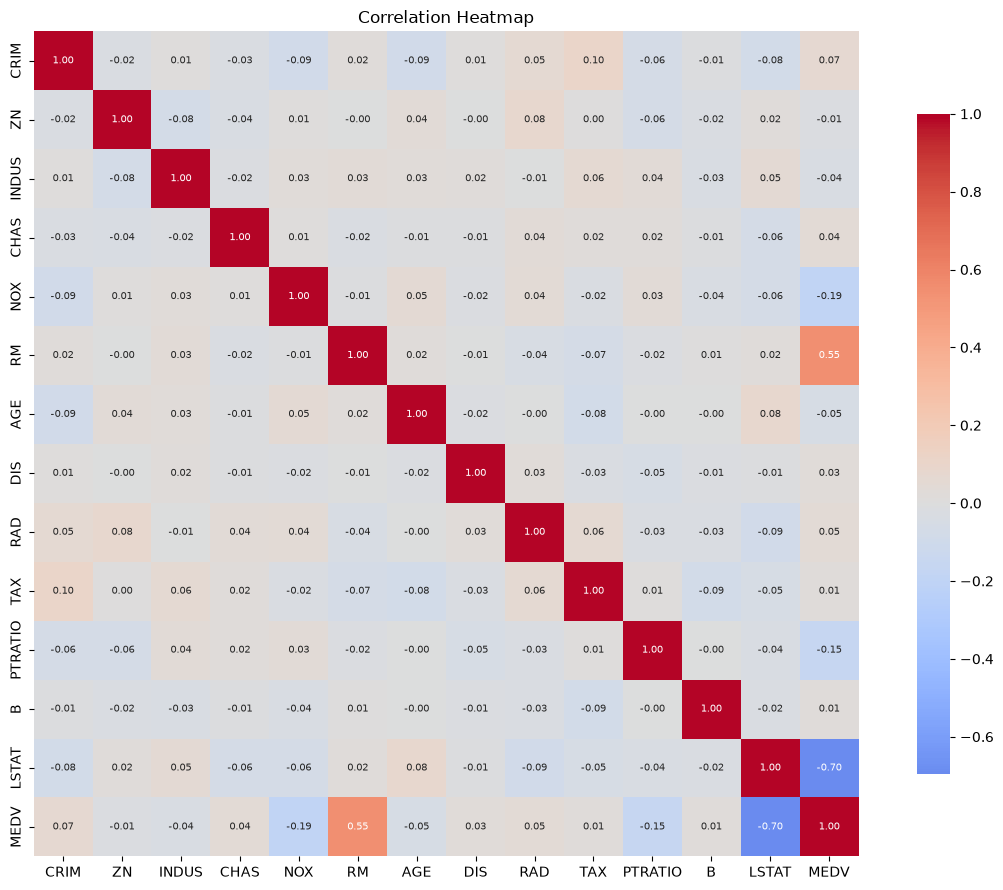

In [10]:
# The heatmap shows how strongly every pair of variables moves together.
# Look at the TARGET row/column to see which features drive the house price.
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## Which features correlate most with the target?

In [11]:
# Sorted list - easier to quote in the written answer than reading the heatmap
corr_with_target = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(ascending=False)
print(corr_with_target.round(3))


RM         0.547
CRIM       0.072
RAD        0.046
CHAS       0.045
DIS        0.028
TAX        0.014
B          0.013
ZN        -0.015
INDUS     -0.037
AGE       -0.052
PTRATIO   -0.154
NOX       -0.187
LSTAT     -0.695
Name: MEDV, dtype: float64


## (b) 1. Split into training (65%) and testing (35%) sets

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 328
Testing rows : 178


## (b) 2. Train the Multiple Linear Regression model

In [13]:
# "Multiple" simply means more than one input feature.
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", round(model.intercept_, 4))


Intercept: 20.1513


## The fitted equation - one coefficient per feature

In [14]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_.round(4)
}).sort_values("Coefficient", key=abs, ascending=False)

coefficients


,Feature,Coefficient
12,LSTAT,-5.6779
5,RM,4.2291
4,NOX,-1.6708
10,PTRATIO,-1.3655
0,CRIM,-0.2430
8,RAD,0.2144
9,TAX,0.2116
1,ZN,-0.1788
11,B,0.1666
7,DIS,0.1615


## (b) 3. Predict house prices on the test set

In [15]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred.round(2)})
comparison.head(10)


,Actual,Predicted
0,22.6,26.13
1,34.0,34.13
2,18.7,22.00
3,30.5,29.05
4,19.5,21.73
5,27.9,28.05
6,8.9,13.53
7,8.5,10.55
8,19.6,21.87
9,18.0,20.86


## (b) 4. Evaluate using MSE, RMSE and MAE

In [16]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("MSE :", round(mse, 4))     # average squared error - punishes big mistakes
print("RMSE:", round(rmse, 4))    # same units as the target ($1000s)
print("MAE :", round(mae, 4))     # average absolute error - easiest to explain
print("R2  :", round(r2, 4))      # share of the variance the model explains


MSE : 7.8368
RMSE: 2.7994
MAE : 2.0604
R2  : 0.8624


## (b) 5. Visualise Actual vs Predicted values

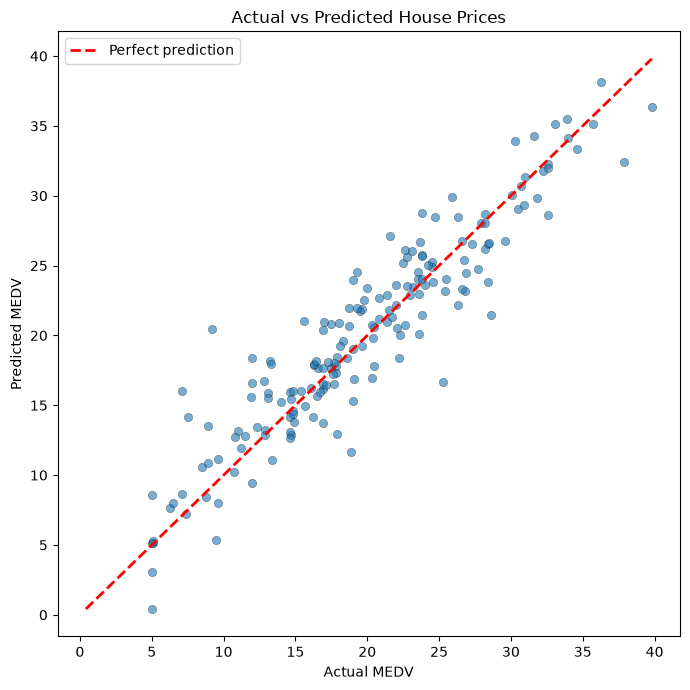

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k", linewidth=0.3)

# The 45-degree line is where a perfect prediction would sit
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")

plt.xlabel("Actual " + TARGET)
plt.ylabel("Predicted " + TARGET)
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()


## Extra: residual plot (shows whether errors are random)

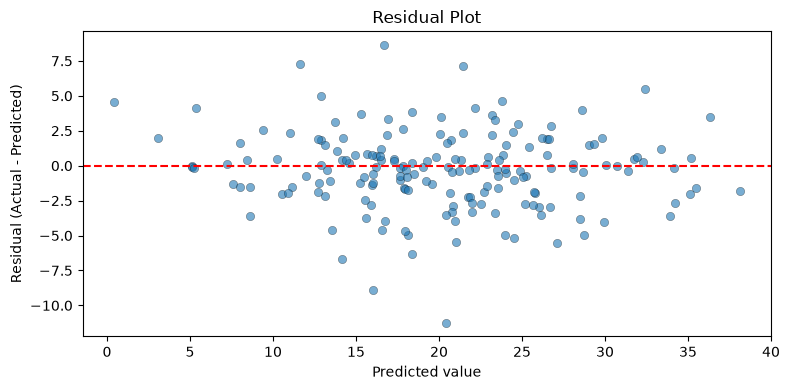

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor="k", linewidth=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted value")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()
